### Coursework Question 1

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.special import logsumexp
import time

#### Run the model

Firstly we will generate a synthetic dataset using the model stated in the question:

In [2]:
def generate_data(T):

    # Generate initial value of x randomly from N(0,1) and set seed for reproducibility
    rng1 = np.random.default_rng(1)
    x0 = stats.norm.rvs(random_state=rng1)

    # Generate values of noise for V and W
    rng2 = np.random.default_rng(2)
    v = stats.norm.rvs(loc=0,scale=np.sqrt(0.1),size=T,random_state=rng2)
    
    rng3 = np.random.default_rng(3)
    w = stats.norm.rvs(loc=0,scale=1,size=T+1,random_state=rng3)

    # Arrays to store hidden state (x) and observations (y)
    x = np.zeros(T+1)
    x[0] = x0
    y = np.zeros(T+1)
    y[0] = 1/20*x0**2 + w[0]

    # Recursively calculate hidden state and observations
    for i in range(1,T+1):
        x[i] = 1/2*x[i-1] + 25*x[i-1]/(1+x[i-1]**2) + 8*np.cos(1.2*i) + v[i-1]
        y[i] = 1/20*x[i]**2 + w[i]

    return x,y

In [3]:
hidden_state,y = generate_data(200)

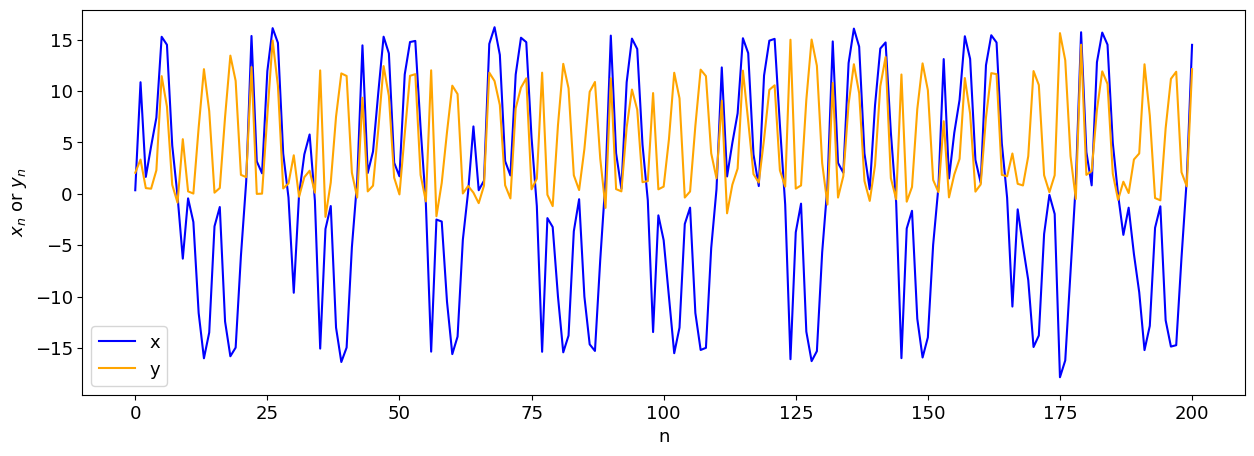

In [39]:
timesteps = np.arange(0,201)
plt.figure(figsize=(15,5))
plt.plot(timesteps,hidden_state,color="blue",label="x")
plt.plot(timesteps,y,color="orange",label="y")
plt.xlabel("n",fontsize=13)
plt.ylabel(r"$x_n$ or $y_n$",fontsize=13)
plt.legend(fontsize=13)
plt.tick_params(labelsize=13)

In [5]:
print(hidden_state[1])
print(hidden_state[50])
print(hidden_state[100])
print(hidden_state[150])
print(hidden_state[199])

10.849309556913859
1.7017334191389344
-4.507911354817338
-13.964848666320274
1.4230078347373902


#### SIR Particle Filter

Firstly, we need to decide which importance density to use. To do this, check how flat the likelihood $p(y_n|x_n)$ is, as if the likelihood is relatively flat, we can use the Bootstrap Proposal, which is simpler.

The model is as follows:

$X_n = \frac{1}{2} X_{n-1} + \frac{25 X_{n-1}}{1+X_{n-1}^2} + 8cos(1.2n) + V_n$ with $V_n \sim N(0,0.1)$

$Y_n = \frac{1}{20} X_n^2 + W_n$ with $W_n \sim N(0,1)$

This means that the transition density and likelihood are:

$f(x_n|x_{n-1}) = \frac{1}{\sqrt{0.2\pi}} \exp(-\frac{1}{0.2}(x_n - (\frac{1}{2}x_{n-1} + \frac{25 x_{n-1}}{1+x_{n-1}^2} + 8cos(1.2n))^2)$

$g(y_n|x_n) = \frac{1}{\sqrt{2\pi}} \exp(-\frac{1}{2}(y_n - \frac{1}{20}x_n^2)^2)$

In [6]:
def g(x,y):
    val = 1/np.sqrt(2*np.pi)*np.exp(-1/2*(y-1/20*x**2)**2)
    return val

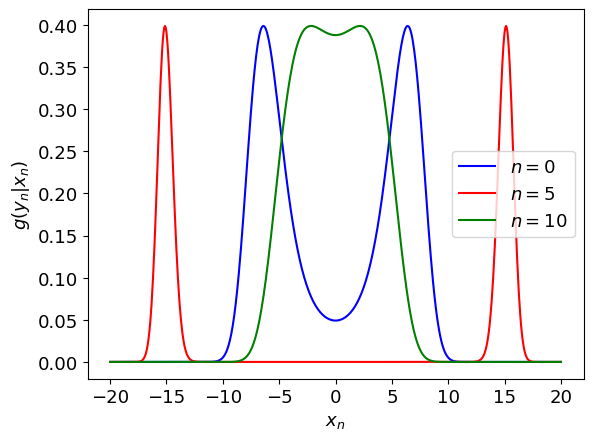

In [8]:
x = np.linspace(-20,20,num=600)
density1 = g(x,y[0])
density2 = g(x,y[5])
density3 = g(x,y[10])
plt.plot(x,density1,color="blue",label=r"$n=0$")
plt.plot(x,density2,color="red",label=r"$n=5$")
plt.plot(x,density3,color="green",label=r"$n=10$")
plt.xlabel(r"$x_n$",fontsize=13)
plt.ylabel(r"$g(y_n|x_n)$",fontsize=13)
plt.legend(fontsize=13)
plt.tick_params(labelsize=13)

Unfortunately, the likelihoods look quite informative, so the Bootstrap proposal is not likely to work well. Therefore we need to calculate the linearised version of the optimal proposal.

To implement the SIR filter, we need to write functions for $f(x_n|x_{n-1})$, $g(y_n|x_n)$, $q(x_n|y_n,x_{n-1})$ and the resampling step. We will use multinomial resampling. To avoid numerical stability issues, we need to work with the log densities instead of the densities themselves.

Also, it turns out that if $X_0 \sim N(0,1)$, the optimal proposal $q(x_0|y_0)$ is also $N(0,1)$, so these cancel out in the weight calculations.

In [9]:
def log_f(x,x_prev,n):

    mean = 1/2*x_prev + 25*x_prev/(1+x_prev**2) + 8*np.cos(1.2*n)
    var = 0.1
    
    val = -1/2*np.log(2*np.pi*var) - 1/(2*var)*(x-mean)**2
    return val

In [10]:
def log_g(x,y):

    mean = 1/20*x**2
    var = 1
    
    val = -1/2*np.log(2*np.pi*var) - 1/(2*var)*(y-mean)**2
    return val

In [11]:
def prop_mean_var(y,x_prev,n):

    psi = 1/2*x_prev + 25*x_prev/(1+x_prev**2) + 8*np.cos(1.2*n)
    B = np.sqrt(0.1)
    C = 1/10*psi
    D = 1

    S = 1/(1/B**2 + C**2)
    m = S*((1/B**2)*psi + C*(y-1/20*psi**2+C*psi)/(D**2))

    return m,S

In [12]:
def log_q(x,m,S):

    val = -1/2*np.log(2*np.pi*S) - 1/(2*S)*(x-m)**2
    return val

In [13]:
def resample(omega, X, lineage, rng):

    # Number of particles
    N = len(X[:,0])

    # Sample offspring from a multinomial distribution with probabilities equal to weights omega
    copies = stats.multinomial.rvs(N,omega,random_state=rng)

    new_X = np.zeros(X.shape)
    new_lineage = np.zeros(lineage.shape)

    # Make new particles by copying each old particle a number of times equal to 'copies'
    k = 0
    for i in range(N):
        if copies[i]>0:
            for _ in range(copies[i]):
                new_X[k,:] = X[i,:]
                new_lineage[k,:] = lineage[i,:]
                k = k+1

    return new_X, new_lineage

In [14]:
def SIR(y,N,run_number):

    # Get the full length of the sequence
    T = len(y)

    # Set array to store history of particles, the indices of the particle ancestors,
    # the sampled particles after each time step and the weights
    X = np.zeros((N,T))
    lineage = np.zeros((N,T))
    samples = np.zeros((N,T))
    weights = np.zeros((N,T))

    # TIME 0
    # Sample from initial proposal (N(0,1)), calculate weights and normalise
    rng = np.random.default_rng(seed=run_number)
    X[:,0] = stats.norm.rvs(size=N,random_state=rng)
    samples[:,0] = X[:,0]

    lineage[:,0] = np.arange(N)
    
    # In the initial case, the transition density and proposal cancel out, leaving omega = g(y0|x0)
    log_omega = log_g(X[:,0],y[0])
    max_val = np.max(log_omega)
    omega = np.exp(log_omega-max_val)/np.sum(np.exp(log_omega-max_val))
    weights[:,0] = omega
    
    X,lineage = resample(omega,X,lineage,rng)

    # TIME n>0
    for n in range(1,T):
        
        m,S = prop_mean_var(y[n],X[:,n-1],n)
        rng = np.random.default_rng(seed=n+run_number)
        X[:,n] = stats.norm.rvs(loc=m,scale=np.sqrt(S),random_state=rng)
        samples[:,n] = X[:,n]
        lineage[:,n] = np.arange(N)
        
        # For n>0, omega = f*g/proposal
        # Need to work with logs to avoid numerical stability issues
        log_omega = log_f(X[:,n],X[:,n-1],n) + log_g(X[:,n],y[n]) - log_q(X[:,n],m,S)
        # Use exp-normalise trick
        max_val = np.max(log_omega)
        omega = np.exp(log_omega-max_val)/np.sum(np.exp(log_omega-max_val))
        weights[:,n] = omega
        
        X, lineage = resample(omega,X,lineage,rng)

    return X, lineage, samples, weights

Run SIR Filter with 50 and 500 particles (and measure time taken):

In [15]:
start_time = time.time()
X_SIR_50, lineage_SIR_50, samples_SIR_50, weights_SIR_50 = SIR(y,50,run_number=0)
end_time = time.time()
SIR_50_time = end_time - start_time

In [16]:
print(SIR_50_time)

0.044873952865600586


In [17]:
start_time = time.time()
X_SIR_500, lineage_SIR_500, samples_SIR_500, weights_SIR_500 = SIR(y,500,run_number=0)
end_time = time.time()
SIR_500_time = end_time - start_time

In [18]:
print(SIR_500_time)

0.11054301261901855


#### FFBSa Smoother

In [19]:
def FFBSa(y,N,n_paths,run_number):

    # Get length of observations
    T = len(y)

    # Run SIR forwards once
    X, lineages, samples, weights = SIR(y,N,run_number=run_number)

    new_samples = np.zeros((n_paths,T))
    new_lineages = np.zeros((n_paths,T))

    possible_ancestors = np.arange(N)

    # For n_paths particles
    for i in range(n_paths):

        # Sample starting particle from final distribution with replacement
        rng1 = np.random.default_rng(i)
        index = stats.randint.rvs(0,N,random_state=rng1)
        new_samples[i,T-1] = samples[index,T-1]
        new_lineages[i,T-1] = lineages[index,T-1]

        # Recursively sample particles at each timestep to generate new lineage
        for j in range(2,T+1):
            n = T-j

            # Calculate probabilities using sample from next time step
            log_p = np.log(weights[:,n]) + log_f(new_samples[i,n+1],samples[:,n],n+1)
            max_val = np.max(log_p)
            p = np.exp(log_p-max_val)/np.sum(np.exp(log_p-max_val))

            # Sample a new ancestor from probabilities and add it to new samples
            rng2 = np.random.default_rng(i*j+j)
            ancestor_index = stats.multinomial.rvs(1,p,random_state=rng2)
            new_samples[i,n] = samples[ancestor_index==1,n]
            new_lineages[i,n] = possible_ancestors[ancestor_index==1]

    return new_samples, new_lineages

Run FFBSa smoother with 50 and 500 particles:

In [20]:
start_time = time.time()
samples_FFBS_50, lineages_FFBS_50 = FFBSa(y,N=50,n_paths=50,run_number=0)
end_time = time.time()
FFBS_50_time = end_time - start_time

In [27]:
print(FFBS_50_time)

0.31429505348205566


In [21]:
start_time = time.time()
samples_FFBS_500, lineages_FFBS_500 = FFBSa(y,N=500,n_paths=500,run_number=0)
end_time = time.time()
FFBS_500_time = end_time - start_time

In [29]:
print(FFBS_500_time)

3.5291690826416016


#### Part (1)

FOR SIR FILTER:

Plot approximations for $p(x_n|y_{0:n})$ using $N=50$:

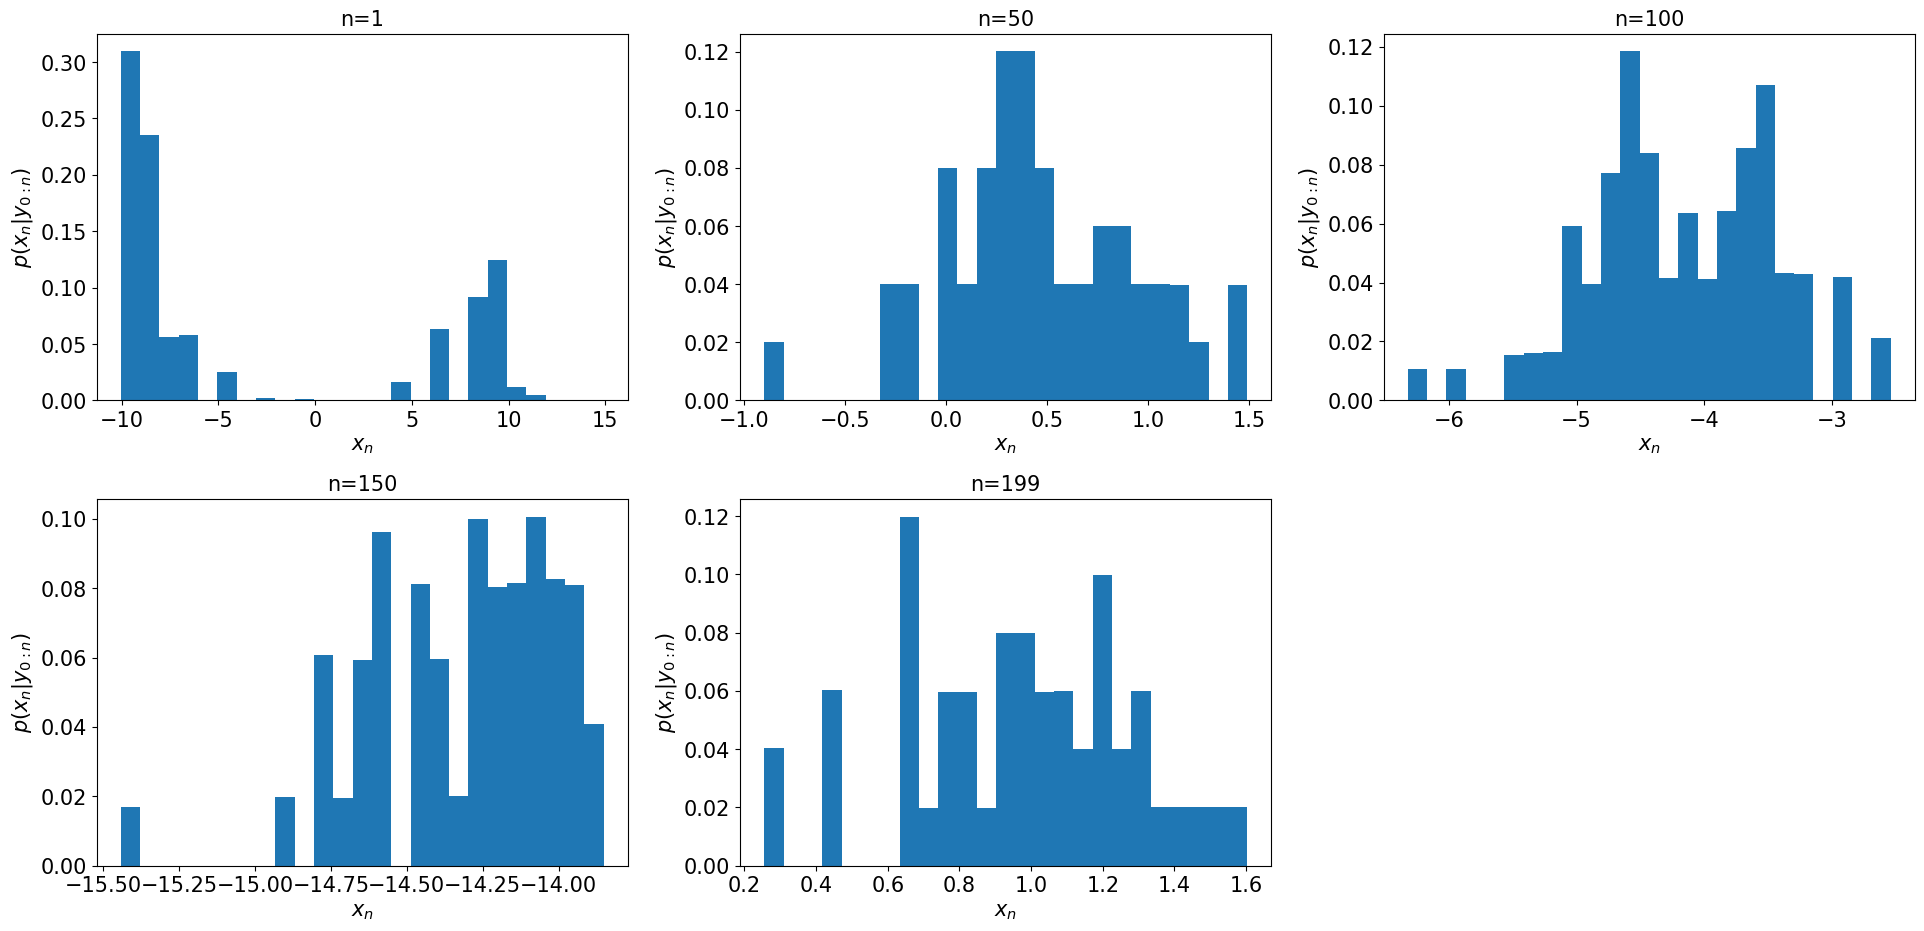

In [23]:
fig, axs = plt.subplots(2,3,figsize=(20,10))

fig.tight_layout(pad=5.0)

axs[0,0].hist(samples_SIR_50[:,1],bins=25,weights=weights_SIR_50[:,1])
axs[0,0].set_title("n=1",fontsize=15)
axs[0,1].hist(samples_SIR_50[:,50],bins=25,weights=weights_SIR_50[:,50])
axs[0,1].set_title("n=50",fontsize=15)
axs[0,2].hist(samples_SIR_50[:,100],bins=25,weights=weights_SIR_50[:,100])
axs[0,2].set_title("n=100",fontsize=15)
axs[1,0].hist(samples_SIR_50[:,150],bins=25,weights=weights_SIR_50[:,150])
axs[1,0].set_title("n=150",fontsize=15)
axs[1,1].hist(samples_SIR_50[:,199],bins=25,weights=weights_SIR_50[:,199])
axs[1,1].set_title("n=199",fontsize=15)
fig.delaxes(axs[1,2])

for ax in axs.flat:
    ax.set_xlabel(r'$x_{n}$', fontsize=15)
    ax.set_ylabel(r'$p(x_n|y_{0:n})$',fontsize=15)
    ax.tick_params(labelsize=15)

Plot approximations for $p(x_n|y_{0:n})$ using $N=500$:

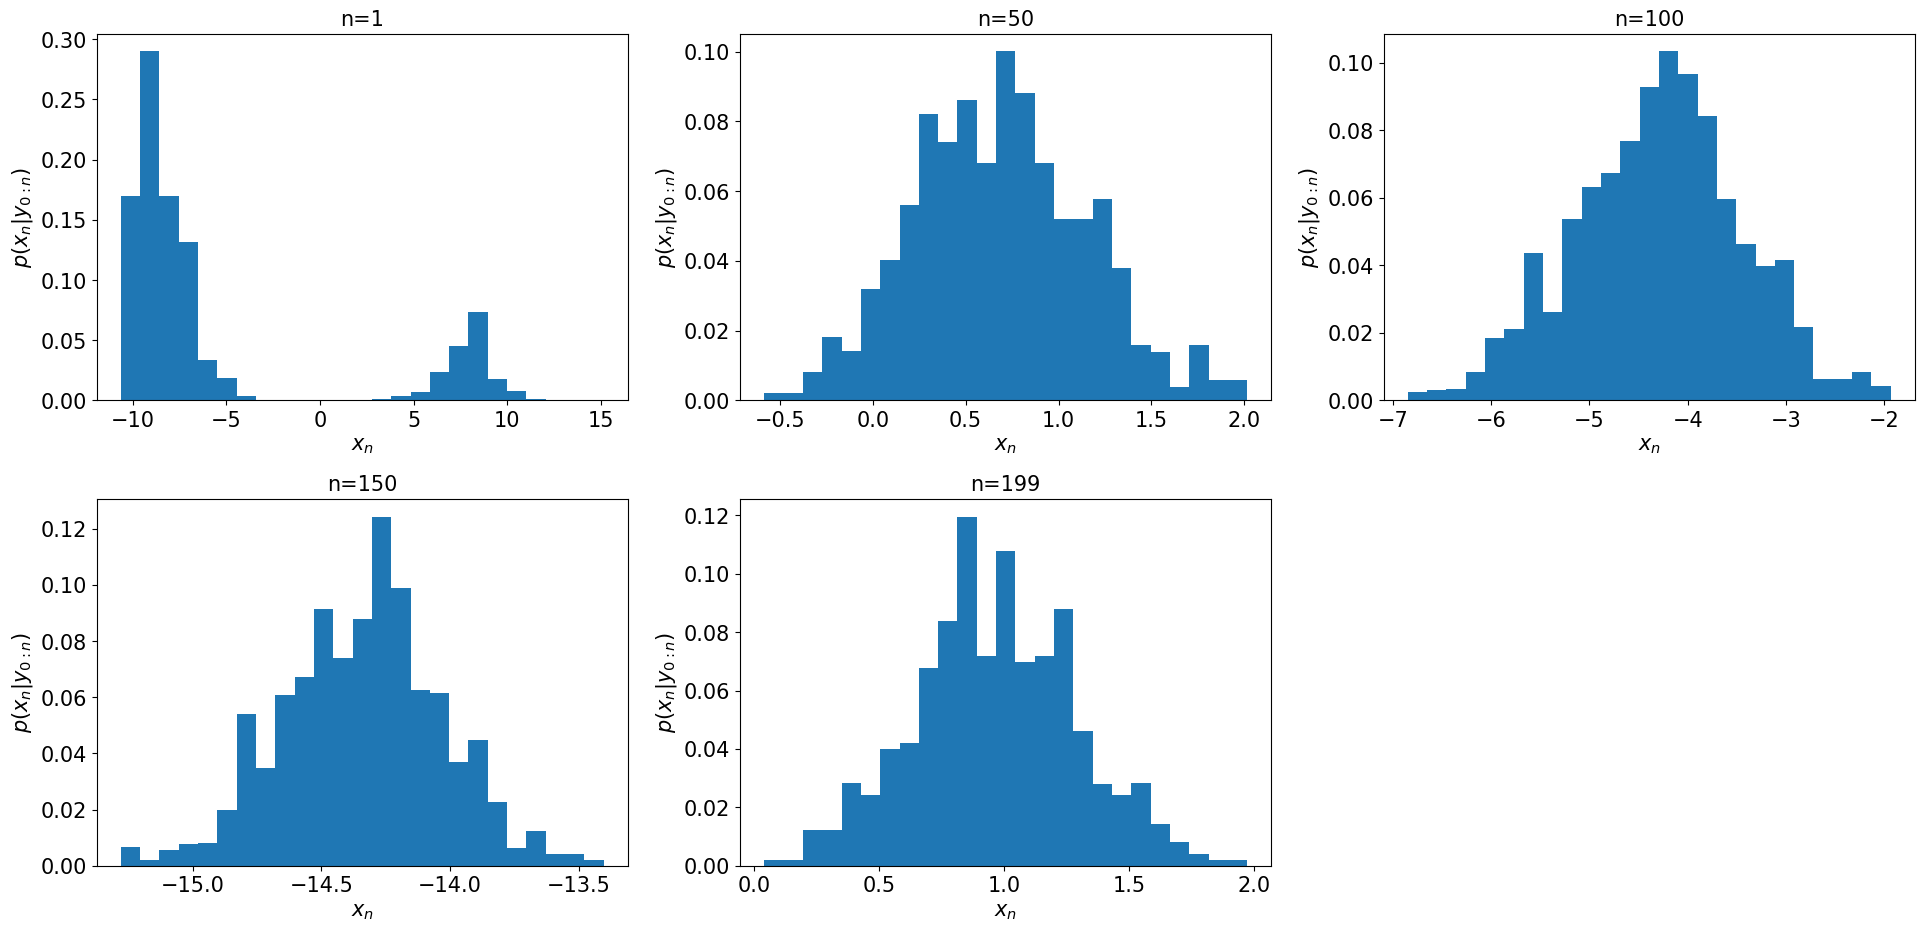

In [24]:
fig, axs = plt.subplots(2,3,figsize=(20,10))

fig.tight_layout(pad=5.0)

axs[0,0].hist(samples_SIR_500[:,1],bins=25,weights=weights_SIR_500[:,1])
axs[0,0].set_title("n=1",fontsize=15)
axs[0,1].hist(samples_SIR_500[:,50],bins=25,weights=weights_SIR_500[:,50])
axs[0,1].set_title("n=50",fontsize=15)
axs[0,2].hist(samples_SIR_500[:,100],bins=25,weights=weights_SIR_500[:,100])
axs[0,2].set_title("n=100",fontsize=15)
axs[1,0].hist(samples_SIR_500[:,150],bins=25,weights=weights_SIR_500[:,150])
axs[1,0].set_title("n=150",fontsize=15)
axs[1,1].hist(samples_SIR_500[:,199],bins=25,weights=weights_SIR_500[:,199])
axs[1,1].set_title("n=199",fontsize=15)
fig.delaxes(axs[1,2])

for ax in axs.flat:
    ax.set_xlabel(r'$x_{n}$', fontsize=15)
    ax.set_ylabel(r'$p(x_n|y_{0:n})$',fontsize=15)
    ax.tick_params(labelsize=15)

Plot approximations for $p(x_n|y_{0:T})$ using $N=50$:

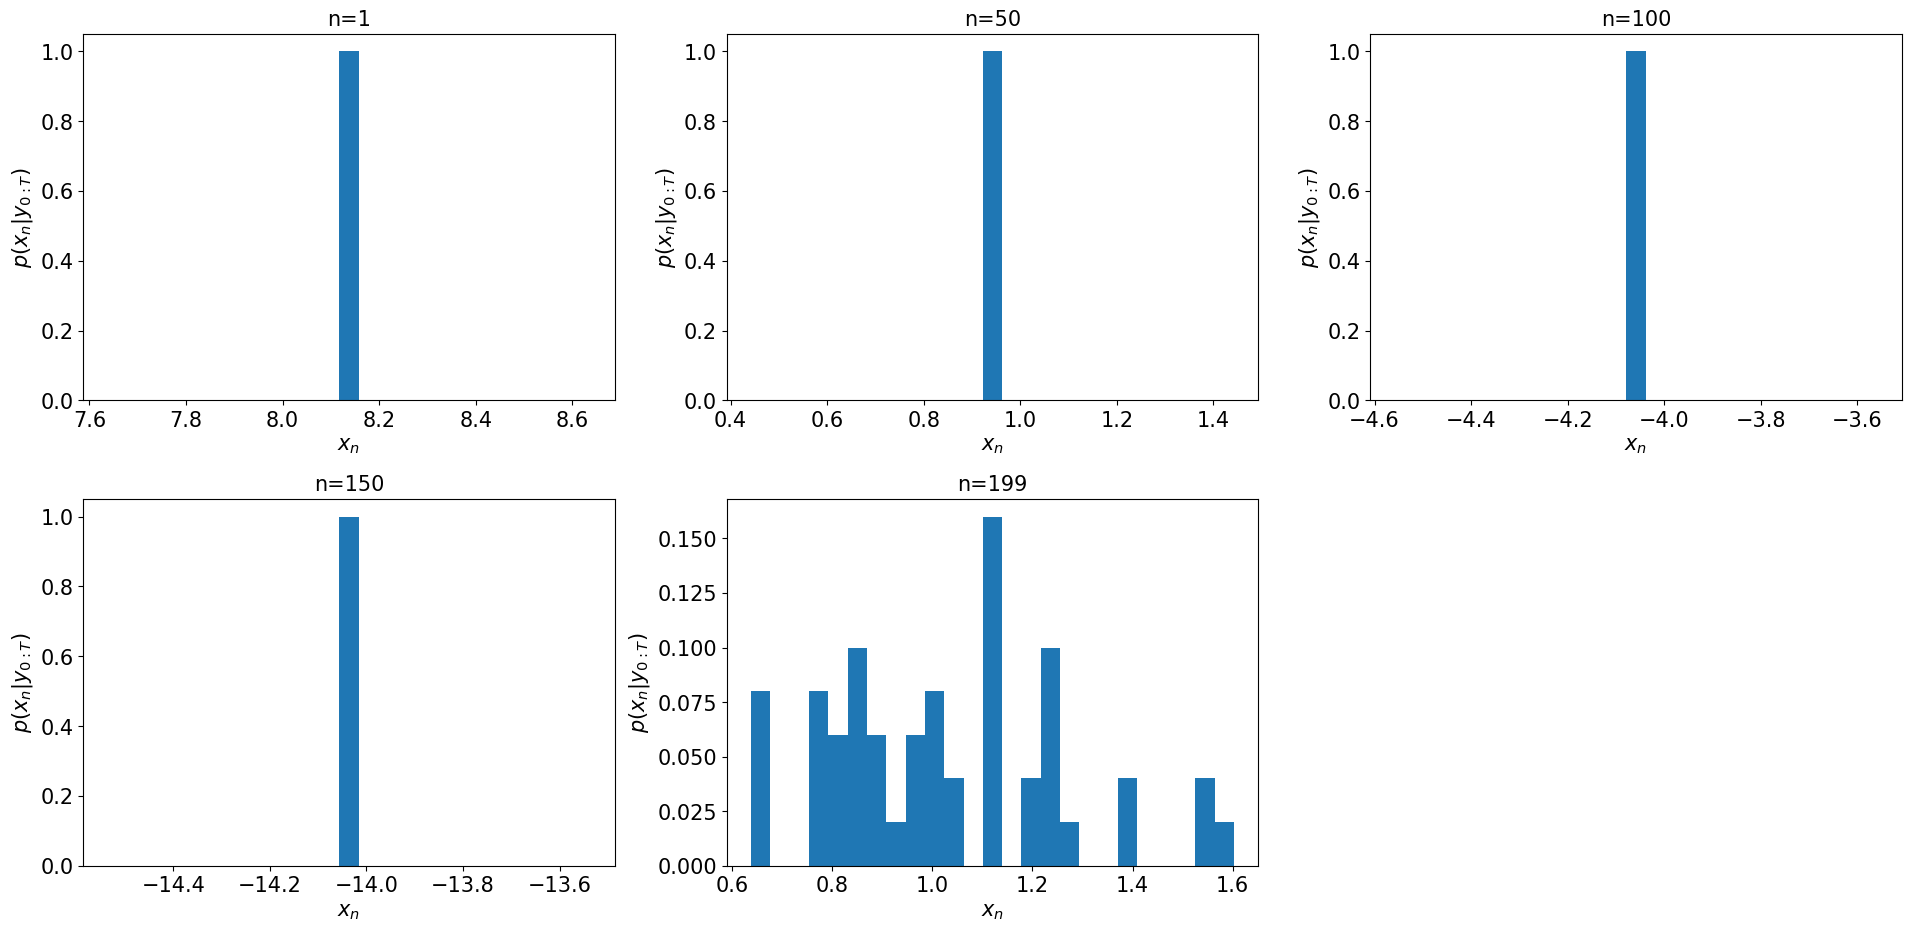

In [25]:
fig, axs = plt.subplots(2,3,figsize=(20,10))

fig.tight_layout(pad=5.0)

weights = np.repeat(1/50,50)

axs[0,0].hist(X_SIR_50[:,1],bins=25,weights=weights)
axs[0,0].set_title("n=1",fontsize=15)
axs[0,1].hist(X_SIR_50[:,50],bins=25,weights=weights)
axs[0,1].set_title("n=50",fontsize=15)
axs[0,2].hist(X_SIR_50[:,100],bins=25,weights=weights)
axs[0,2].set_title("n=100",fontsize=15)
axs[1,0].hist(X_SIR_50[:,150],bins=25,weights=weights)
axs[1,0].set_title("n=150",fontsize=15)
axs[1,1].hist(X_SIR_50[:,199],bins=25,weights=weights)
axs[1,1].set_title("n=199",fontsize=15)
fig.delaxes(axs[1,2])

for ax in axs.flat:
    ax.set_xlabel(r'$x_{n}$', fontsize=15)
    ax.set_ylabel(r'$p(x_n|y_{0:T})$',fontsize=15)
    ax.tick_params(labelsize=15)

Plot approximations for $p(x_n|y_{0:T})$ using $N=500$:

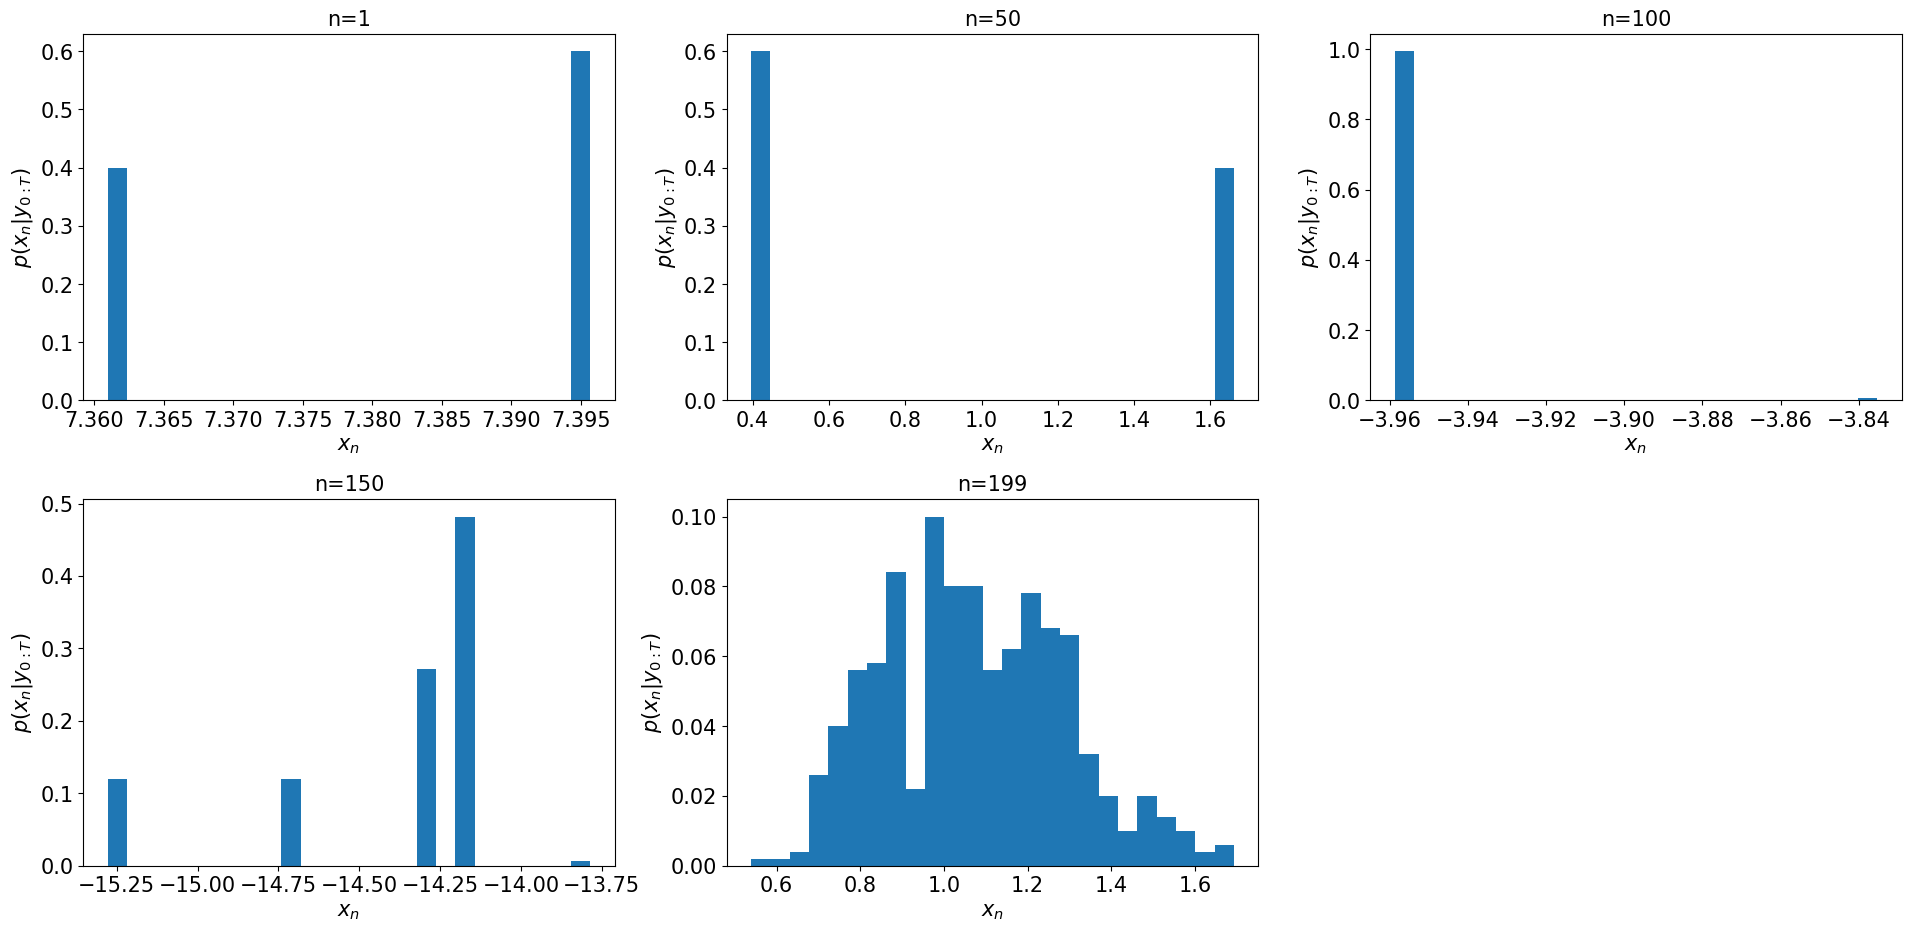

In [26]:
fig, axs = plt.subplots(2,3,figsize=(20,10))

fig.tight_layout(pad=5.0)

weights = np.repeat(1/500,500)

axs[0,0].hist(X_SIR_500[:,1],bins=25,weights=weights)
axs[0,0].set_title("n=1",fontsize=15)
axs[0,1].hist(X_SIR_500[:,50],bins=25,weights=weights)
axs[0,1].set_title("n=50",fontsize=15)
axs[0,2].hist(X_SIR_500[:,100],bins=25,weights=weights)
axs[0,2].set_title("n=100",fontsize=15)
axs[1,0].hist(X_SIR_500[:,150],bins=25,weights=weights)
axs[1,0].set_title("n=150",fontsize=15)
axs[1,1].hist(X_SIR_500[:,199],bins=25,weights=weights)
axs[1,1].set_title("n=199",fontsize=15)
fig.delaxes(axs[1,2])

for ax in axs.flat:
    ax.set_xlabel(r'$x_{n}$', fontsize=15)
    ax.set_ylabel(r'$p(x_n|y_{0:T})$',fontsize=15)
    ax.tick_params(labelsize=15)

FOR FFBSa SMOOTHER:

Plot approximations for $p(x_n|y_{0:T})$ using $N=50$:

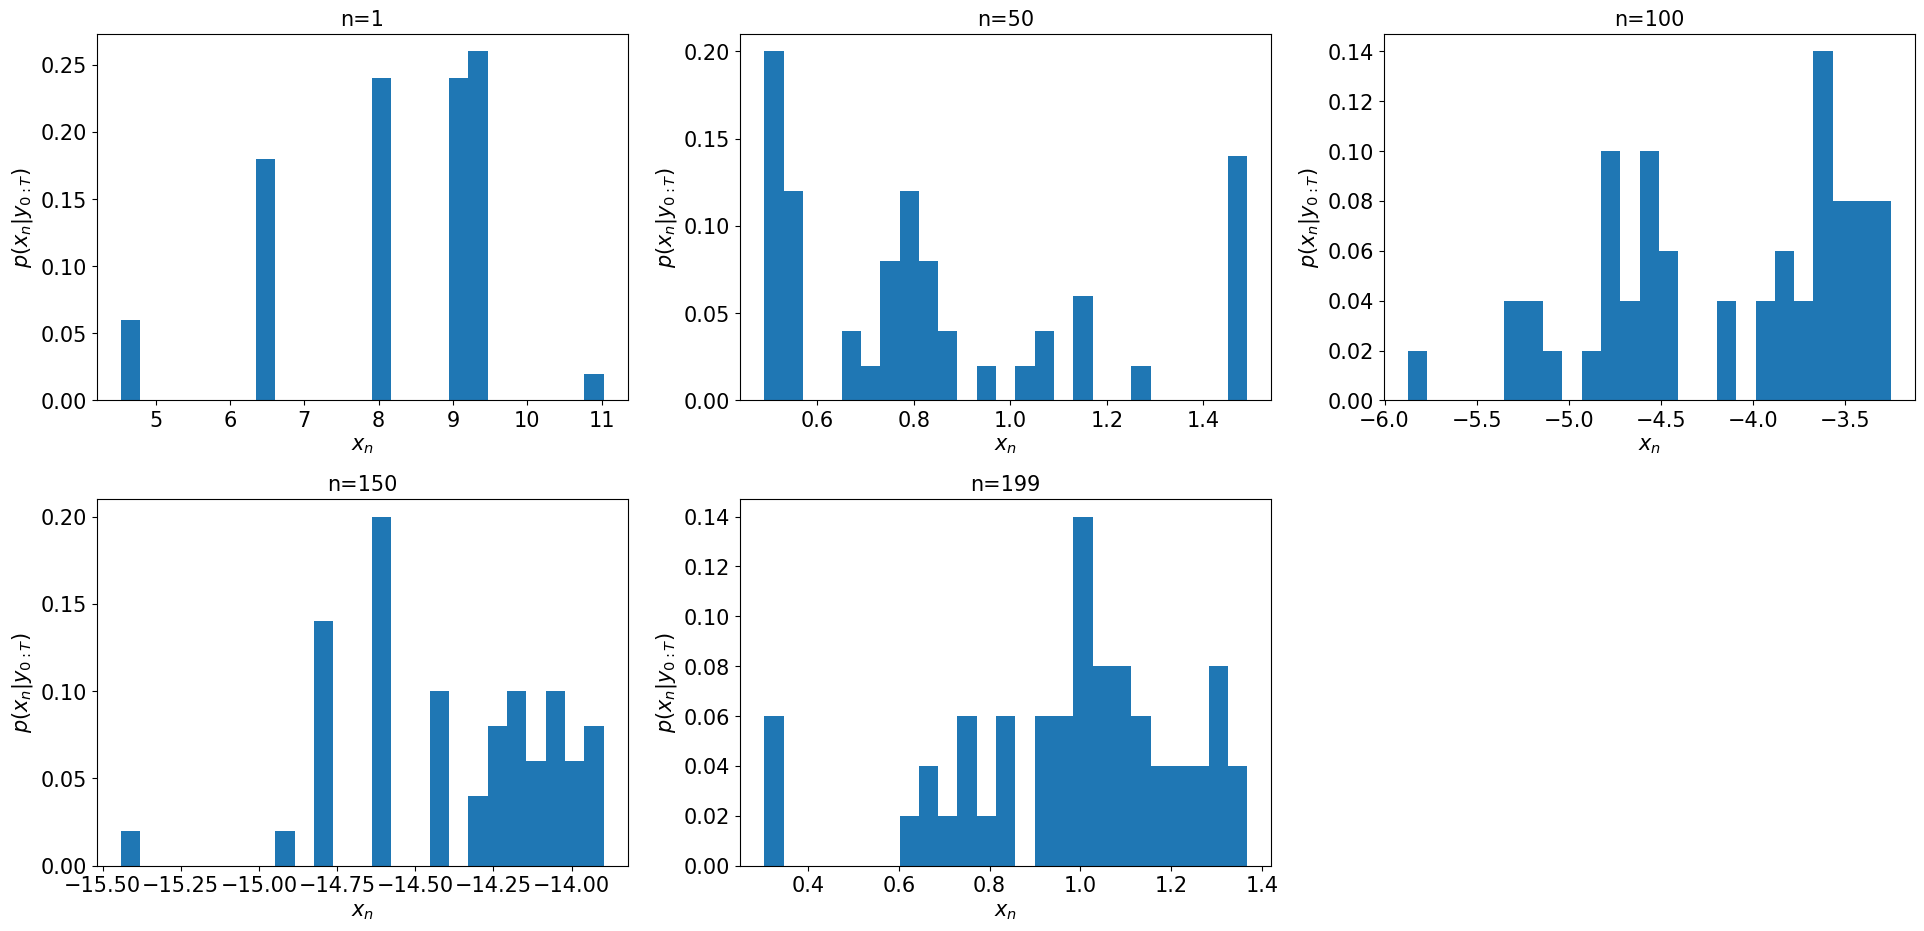

In [27]:
fig, axs = plt.subplots(2,3,figsize=(20,10))

fig.tight_layout(pad=5.0)

weights = np.repeat(1/50,50)

axs[0,0].hist(samples_FFBS_50[:,1],bins=25,weights=weights)
axs[0,0].set_title("n=1",fontsize=15)
axs[0,1].hist(samples_FFBS_50[:,50],bins=25,weights=weights)
axs[0,1].set_title("n=50",fontsize=15)
axs[0,2].hist(samples_FFBS_50[:,100],bins=25,weights=weights)
axs[0,2].set_title("n=100",fontsize=15)
axs[1,0].hist(samples_FFBS_50[:,150],bins=25,weights=weights)
axs[1,0].set_title("n=150",fontsize=15)
axs[1,1].hist(samples_FFBS_50[:,199],bins=25,weights=weights)
axs[1,1].set_title("n=199",fontsize=15)
fig.delaxes(axs[1,2])

for ax in axs.flat:
    ax.set_xlabel(r'$x_{n}$', fontsize=15)
    ax.set_ylabel(r'$p(x_n|y_{0:T})$',fontsize=15)
    ax.tick_params(labelsize=15)

Plot approximations for $p(x_n|y_{0:T})$ using $N=500$:

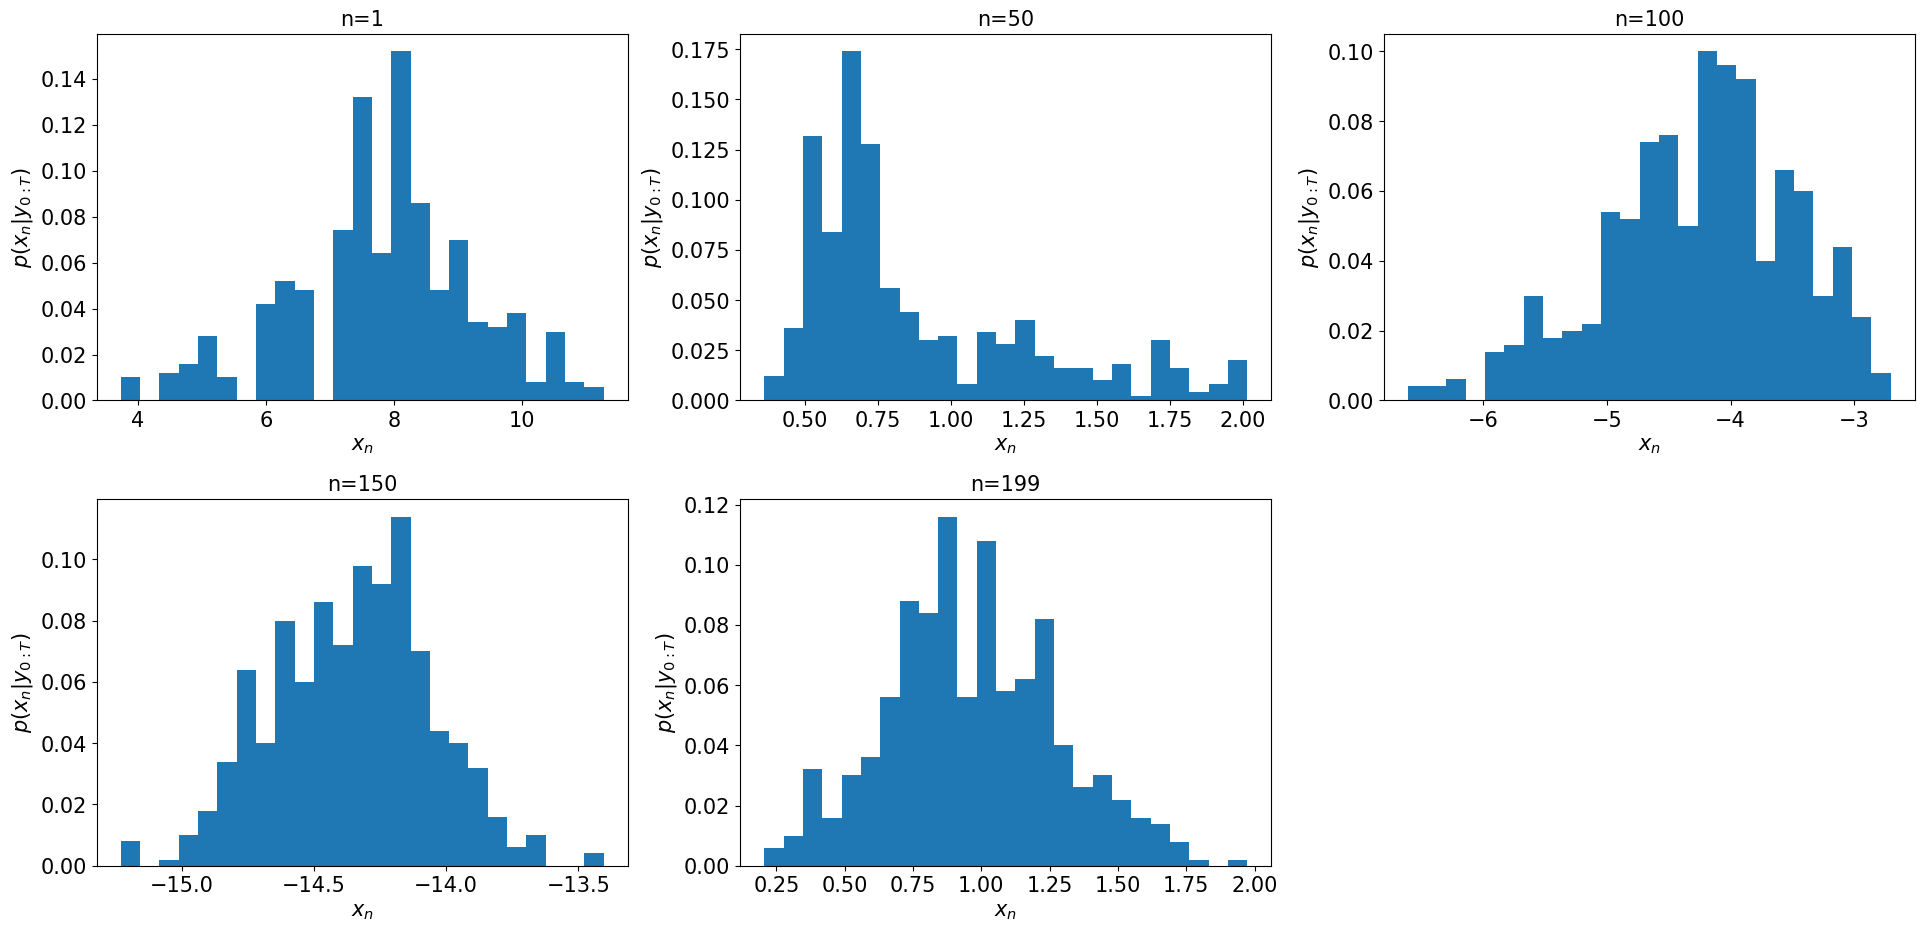

In [28]:
fig, axs = plt.subplots(2,3,figsize=(20,10))

fig.tight_layout(pad=5.0)

weights = np.repeat(1/500,500)

axs[0,0].hist(samples_FFBS_500[:,1],bins=25,weights=weights)
axs[0,0].set_title("n=1",fontsize=15)
axs[0,1].hist(samples_FFBS_500[:,50],bins=25,weights=weights)
axs[0,1].set_title("n=50",fontsize=15)
axs[0,2].hist(samples_FFBS_500[:,100],bins=25,weights=weights)
axs[0,2].set_title("n=100",fontsize=15)
axs[1,0].hist(samples_FFBS_500[:,150],bins=25,weights=weights)
axs[1,0].set_title("n=150",fontsize=15)
axs[1,1].hist(samples_FFBS_500[:,199],bins=25,weights=weights)
axs[1,1].set_title("n=199",fontsize=15)
fig.delaxes(axs[1,2])

for ax in axs.flat:
    ax.set_xlabel(r'$x_{n}$', fontsize=15)
    ax.set_ylabel(r'$p(x_n|y_{0:T})$',fontsize=15)
    ax.tick_params(labelsize=15)

#### Part (2)

Plot number of unique particles against timestep for $N=50$:

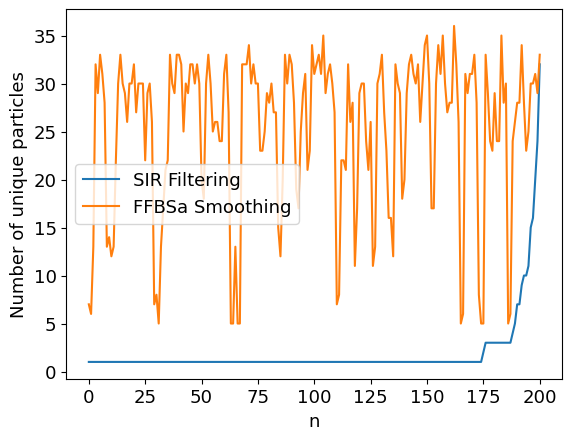

In [29]:
unique_particles_SIR = []
unique_particles_FFBS = []
for i in range(len(y)):
    unique_particles_SIR.append(len(np.unique(X_SIR_50[:,i])))
    unique_particles_FFBS.append(len(np.unique(samples_FFBS_50[:,i])))
plt.plot(timesteps,unique_particles_SIR,label="SIR Filtering")
plt.plot(timesteps,unique_particles_FFBS,label="FFBSa Smoothing")
plt.xlabel("n",fontsize=13)
plt.ylabel("Number of unique particles",fontsize=13)
plt.tick_params(labelsize=13)
plt.legend(fontsize=13)

Plot the particle index against timestep. The particle index tracks which of the 50 particles each particle originated from at each timestep.

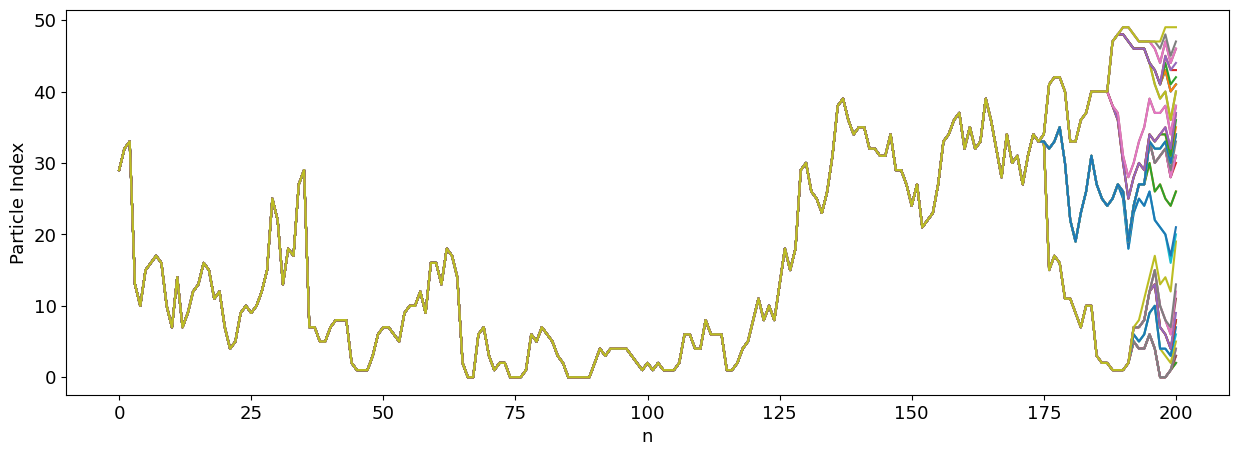

In [30]:
plt.figure(figsize=(15,5))
for n in range(1,50):
    plt.plot(timesteps,lineage_SIR_50[n,:])
plt.xlabel("n",fontsize=13)
plt.ylabel("Particle Index",fontsize=13)
plt.tick_params(labelsize=13)

The graph above shows clearly that SIR suffers from path degeneracy. This is because all 50 particles looking back from the end of the filter appear to originate from a single particle (starting with index 30) at the start.

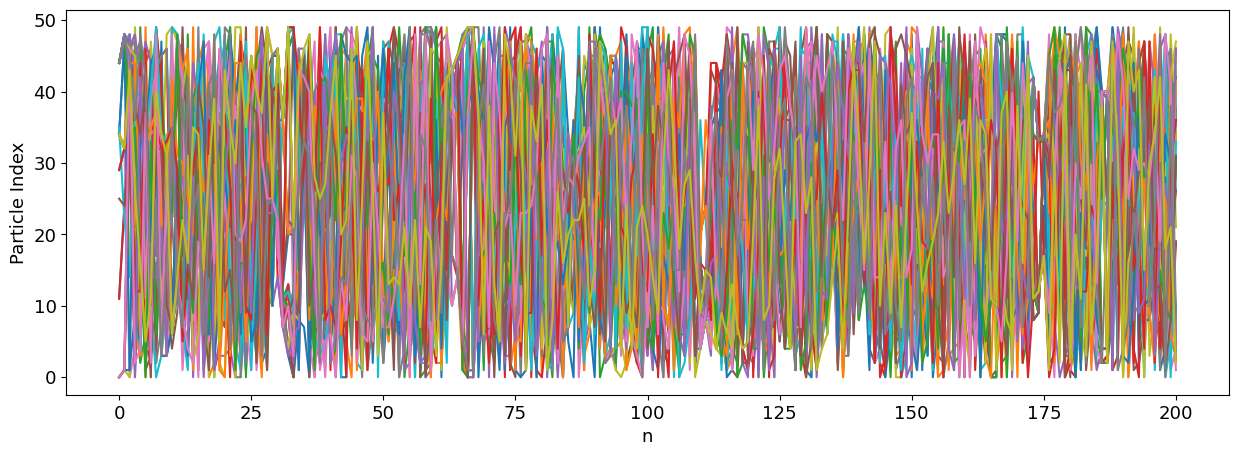

In [31]:
plt.figure(figsize=(15,5))
for n in range(1,50):
    plt.plot(timesteps,lineages_FFBS_50[n,:])
plt.xlabel("n",fontsize=13)
plt.ylabel("Particle Index",fontsize=13)
plt.tick_params(labelsize=13)

We see that FFBSa does not suffer from path degeneracy because the particles are different at all timesteps rather than just towards the end. At each timestep, the particles appear to mostly come from different origins rather than the same original particle.

#### Part (3)

Plot $E(X_n|y_{0:n})$ using the filtering distributions, $E(X_n|y_{0:T})$ using the final state from (a) and $E(X_n|y_{0:T})$ using the smoothing distributions from (b):

Use $N=50$:

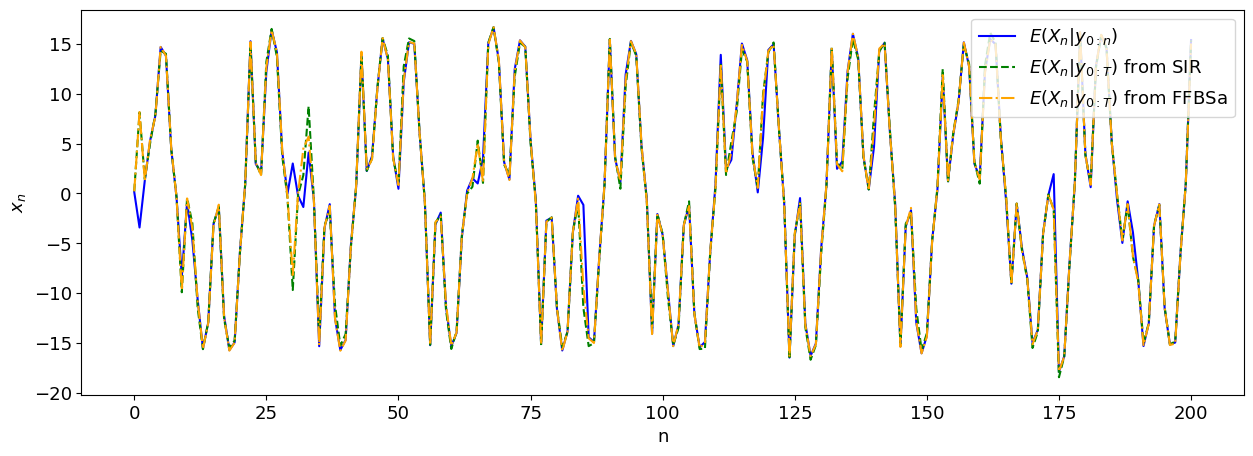

In [34]:
plt.figure(figsize=(15,5))
plt.plot(timesteps,np.sum(samples_SIR_50*weights_SIR_50,axis=0),color="blue",label=r"$E(X_n|y_{0:n})$")
plt.plot(timesteps,np.mean(X_SIR_50,axis=0),label=r"$E(X_n|y_{0:T}$) from SIR",color="green",linestyle="--")
plt.plot(timesteps,np.mean(samples_FFBS_50,axis=0),label=r"$E(X_n|y_{0:T}$) from FFBSa",color="orange",linestyle="-.")
plt.xlabel("n",fontsize=13)
plt.ylabel("$x_n$",fontsize=13)
plt.legend(fontsize=13)
plt.tick_params(labelsize=13)

Use $N=500$:

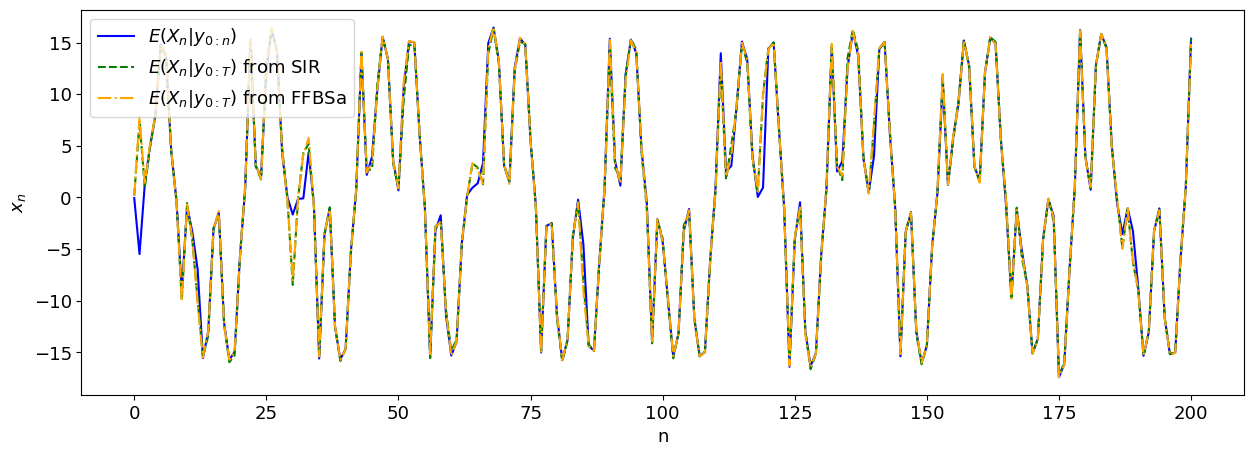

In [33]:
plt.figure(figsize=(15,5))
plt.plot(timesteps,np.sum(samples_SIR_500*weights_SIR_500,axis=0),color="blue",label=r"$E(X_n|y_{0:n})$")
plt.plot(timesteps,np.mean(X_SIR_500,axis=0),label=r"$E(X_n|y_{0:T})$ from SIR",color="green",linestyle="--")
plt.plot(timesteps,np.mean(samples_FFBS_500,axis=0),label=r"$E(X_n|y_{0:T})$ from FFBSa",color="orange",linestyle="-.")
plt.xlabel("n",fontsize=13)
plt.ylabel("$x_n$",fontsize=13)
plt.legend(fontsize=13)
plt.tick_params(labelsize=13)

Plot $\text{Var}(X_n|y_{0:n})$ using the filtering distributions, $\text{Var}(X_n|y_{0:T})$ using the final state from (a) and $\text{Var}(X_n|y_{0:T})$ using the smoothing distributions from (b):

Use $N=50$:

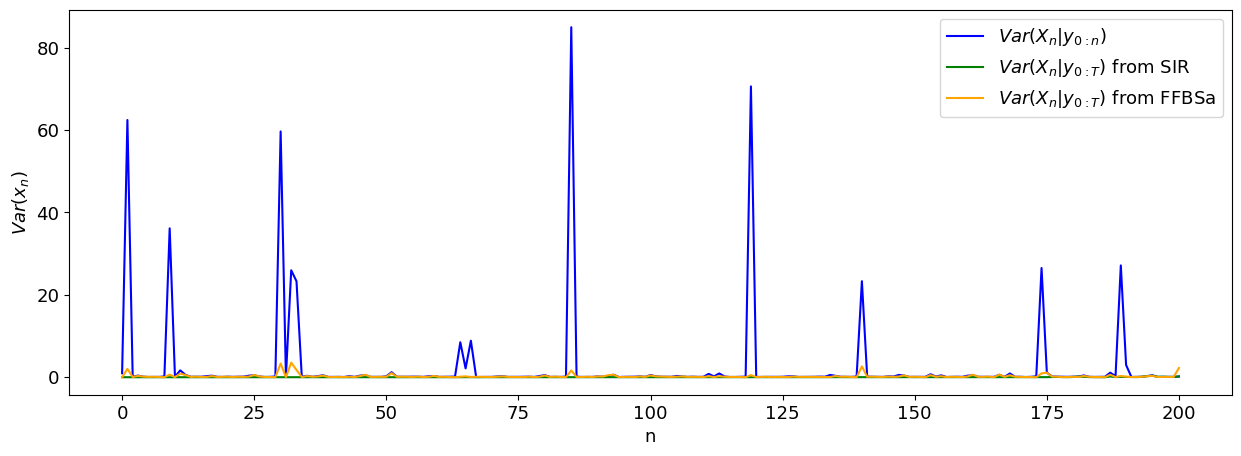

In [35]:
plt.figure(figsize=(15,5))
mean1 = np.sum(samples_SIR_50*weights_SIR_50,axis=0)
plt.plot(timesteps,np.sum(weights_SIR_50*(samples_SIR_50 - mean1)**2,axis=0),color="blue",label=r"$Var(X_n|y_{0:n})$")
mean2 = np.mean(X_SIR_50,axis=0)
plt.plot(timesteps,np.mean((X_SIR_50-mean2)**2,axis=0),color="green",label=r"$Var(X_n|y_{0:T})$ from SIR")
mean3 = np.mean(samples_FFBS_50,axis=0)
plt.plot(timesteps,np.mean((samples_FFBS_50-mean3)**2,axis=0),color="orange",label=r"$Var(X_n|y_{0:T})$ from FFBSa")
plt.xlabel("n",fontsize=13)
plt.ylabel(r"$Var(x_n)$",fontsize=13)
plt.legend(fontsize=13)
plt.tick_params(labelsize=13)

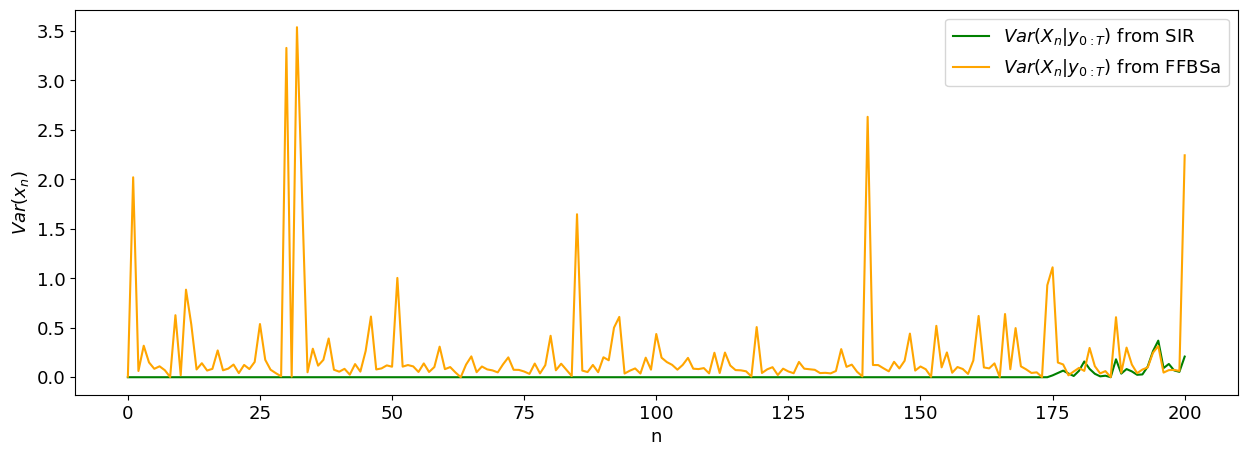

In [36]:
plt.figure(figsize=(15,5))
mean2 = np.mean(X_SIR_50,axis=0)
plt.plot(timesteps,np.mean((X_SIR_50-mean2)**2,axis=0),color="green",label=r"$Var(X_n|y_{0:T})$ from SIR")
mean3 = np.mean(samples_FFBS_50,axis=0)
plt.plot(timesteps,np.mean((samples_FFBS_50-mean3)**2,axis=0),color="orange",label=r"$Var(X_n|y_{0:T})$ from FFBSa")
plt.xlabel("n",fontsize=13)
plt.ylabel(r"$Var(x_n)$",fontsize=13)
plt.tick_params(labelsize=13)
plt.legend(fontsize=13)

Use $N=500$:

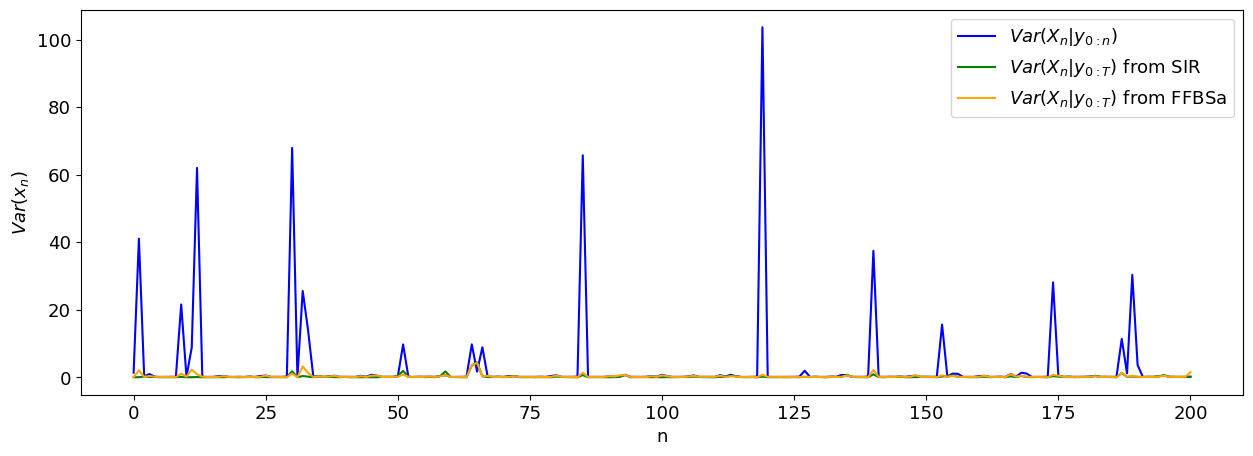

In [37]:
plt.figure(figsize=(15,5))
mean1 = np.sum(samples_SIR_500*weights_SIR_500,axis=0)
plt.plot(timesteps,np.sum(weights_SIR_500*(samples_SIR_500 - mean1)**2,axis=0),color="blue",label=r"$Var(X_n|y_{0:n})$")
mean2 = np.mean(X_SIR_500,axis=0)
plt.plot(timesteps,np.mean((X_SIR_500-mean2)**2,axis=0),color="green",label=r"$Var(X_n|y_{0:T})$ from SIR")
mean3 = np.mean(samples_FFBS_500,axis=0)
plt.plot(timesteps,np.mean((samples_FFBS_500-mean3)**2,axis=0),color="orange",label=r"$Var(X_n|y_{0:T})$ from FFBSa")
plt.xlabel("n",fontsize=13)
plt.ylabel(r"$Var(x_n)$",fontsize=13)
plt.legend(fontsize=13)
plt.tick_params(labelsize=13)

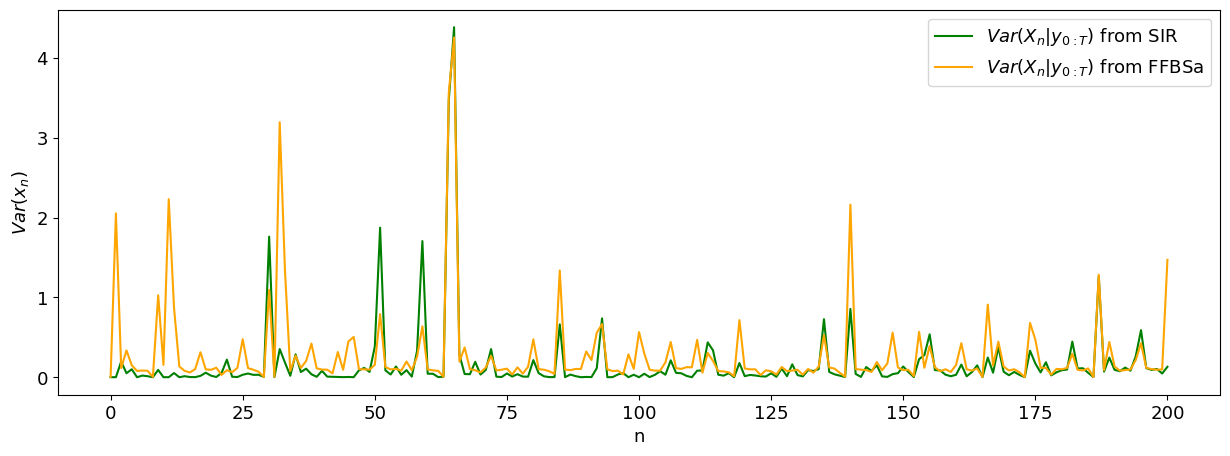

In [38]:
plt.figure(figsize=(15,5))
mean2 = np.mean(X_SIR_500,axis=0)
plt.plot(timesteps,np.mean((X_SIR_500-mean2)**2,axis=0),color="green",label=r"$Var(X_n|y_{0:T})$ from SIR")
mean3 = np.mean(samples_FFBS_500,axis=0)
plt.plot(timesteps,np.mean((samples_FFBS_500-mean3)**2,axis=0),color="orange",label=r"$Var(X_n|y_{0:T})$ from FFBSa")
plt.xlabel("n",fontsize=13)
plt.ylabel(r"$Var(x_n)$",fontsize=13)
plt.tick_params(labelsize=13)
plt.legend(fontsize=13)

#### Part (4)

Procedure for SIR:

1. Run SIR filter storing the value of $T^i = \sum_{k=1}^n x_k^i$ for each particle, along the _resampled path_. To ensure this is done along the resampled path, we resample the value of the sum along with $x$.

2. Compute $S_n = \frac{1}{N}\sum_{i=1}^N T^i$.

Procedure for FFBSa:

1. Run FFBSa normally to get a new, diverse series of paths with sample $x_n^i$ for time step $n$ and particle/path $i$.

2. Compute $S_n = \frac{1}{N} \sum_{i=1}^N \sum_{k=1}^n x_k^i$.

Rewrite SIR algorithm to recursively compute the additive functional inside:

In [375]:
def resample_functional(omega, X, lineage, running_sum, rng):

    # Number of particles
    N = len(X[:,0])

    # Sample offspring from a multinomial distribution with probabilities equal to weights omega
    # copies = stats.multinomial.rvs(N,omega,random_state=rng)
    copies = stats.multinomial.rvs(N,omega,random_state=rng)

    new_X = np.zeros(X.shape)
    new_lineage = np.zeros(lineage.shape)
    new_running_sum = np.zeros(running_sum.shape)

    # Make new particles by copying each old particle a number of times equal to 'copies'
    k = 0
    for i in range(N):
        if copies[i]>0:
            for _ in range(copies[i]):
                new_X[k,:] = X[i,:]
                new_lineage[k,:] = lineage[i,:]
                new_running_sum[k] = running_sum[i]
                k = k+1

    return new_X, new_lineage, new_running_sum

In [394]:
def SIR_functional(y,N,run_number):

    # Get the full length of the sequence
    T = len(y)

    # Set array to store history of particles, the indices of the particle ancestors,
    # the sampled particles after each time step and the weights
    X = np.zeros((N,T))
    lineage = np.zeros((N,T))
    samples = np.zeros((N,T))
    weights = np.zeros((N,T))

    # Set array to store sum_s for each particle at each timestep
    sum_s = np.zeros((N,T))
    running_sum = np.zeros(N)

    # TIME 0
    # Sample from initial proposal (N(0,1)), calculate weights and normalise
    rng = np.random.default_rng(seed=run_number)
    X[:,0] = stats.norm.rvs(size=N,random_state=rng)
    samples[:,0] = X[:,0]
    running_sum[:] = 0

    lineage[:,0] = np.arange(N)
    
    # In the initial case, the transition density and proposal cancel out, leaving omega = g(y0|x0)
    log_omega = log_g(X[:,0],y[0])
    max_val = np.max(log_omega)
    omega = np.exp(log_omega-max_val)/np.sum(np.exp(log_omega-max_val))
    weights[:,0] = omega
    
    X,lineage,running_sum = resample_functional(omega,X,lineage,running_sum,rng)
    sum_s[:,0] = running_sum

    # TIME n>0
    for n in range(1,T):
        
        m,S = prop_mean_var(y[n],X[:,n-1],n)
        rng = np.random.default_rng(seed=n*run_number+n)
        X[:,n] = stats.norm.rvs(loc=m,scale=np.sqrt(S),random_state=rng)
        samples[:,n] = X[:,n]
        lineage[:,n] = np.arange(N)
        running_sum[:] += X[:,n]
        
        # For n>0, omega = f*g/proposal
        # Need to work with logs to avoid numerical stability issues
        log_omega = log_f(X[:,n],X[:,n-1],n) + log_g(X[:,n],y[n]) - log_q(X[:,n],m,S)
        # Use exp-normalise trick
        max_val = np.max(log_omega)
        omega = np.exp(log_omega-max_val)/np.sum(np.exp(log_omega-max_val))
        weights[:,n] = omega
        
        X, lineage, running_sum = resample_functional(omega,X,lineage,running_sum,rng)
        sum_s[:,n] = running_sum

    return X, lineage, sum_s, samples, weights

In [286]:
def smoothed_additive_functional(samples,weights=None,mode="SIR"):
    # If weights are provided, then we are calculating the estimate using SIR
    T = len(samples[0,:])
    S = np.zeros(T)
    if mode=="SIR":
        S[0] = np.sum(samples[:,0]*weights[:,0])
        for i in range(1,T):
            S[i] = S[i-1] + np.sum(samples[:,i]*weights[:,i])
    else:
        S[0] = np.mean(samples[:,0])
        for i in range(1,T):
            S[i] = S[i-1] + np.mean(samples[:,i])
    return S

In [314]:
def smoothed_additive_functional2(run_number):
    
    S = np.zeros(201)
    
    for n in range(1,201):
        X, lineage, samples, weights = SIR(y,50,T=n,run_number=run_number)
        S[n] = 1/50*np.sum(X)
    return S

Compute the smoothed additive functional using 50 independent runs and calculate the variance across the runs. Repeat for $N=500$, $N=1000$ and $N=2000$:

In [475]:
S_500 = np.zeros((50,201))
for run_number in range(50):
    X, lineage, sum_s, samples, weights = SIR_functional(y,500,run_number)
    S_500[run_number,:] = np.mean(sum_s,axis=0)

In [476]:
S_1000 = np.zeros((50,201))
for run_number in range(50):
    X, lineage, sum_s, samples, weights = SIR_functional(y,1000,run_number)
    S_1000[run_number,:] = np.mean(sum_s,axis=0)

In [482]:
S_2000 = np.zeros((50,201))
for run_number in range(50):
    X, lineage, sum_s, samples, weights = SIR_functional(y,2000,run_number)
    S_2000[run_number,:] = np.mean(sum_s,axis=0)

Text(0, 0.5, '$\\text{Var}(S_n^{\\theta})$')

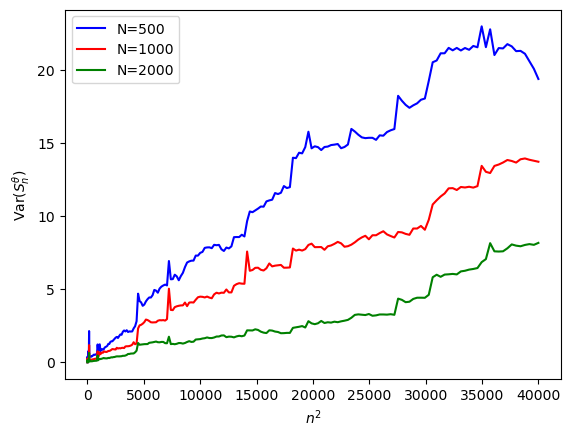

In [487]:
plt.plot(timesteps**2,np.var(S_500,axis=0),color="blue",label="N=500")
plt.plot(timesteps**2,np.var(S_1000,axis=0),color="red",label="N=1000")
plt.plot(timesteps**2,np.var(S_2000,axis=0),color="green",label="N=2000")
plt.legend()
plt.xlabel(r"$n^2$")
plt.ylabel(r"$\text{Var}(S_n^{\theta})$")

Compute smoothed additive functional with FFBSa by adding up the samples along a path, using the standard output from FFBSa. Again use increasing numbers of particles: $N=500$, $N=1000$ and $N=2000$:

In [501]:
S_500 = np.zeros((50,201))
for run_number in range(50):
    samples, lineage = FFBSa(y,500,n_paths=500,run_number=run_number)
    sum_s = np.cumsum(samples,axis=1)
    S_500[run_number,:] = np.mean(sum_s,axis=0)

In [502]:
S_1000 = np.zeros((50,201))
for run_number in range(50):
    samples, lineage = FFBSa(y,1000,n_paths=1000,run_number=run_number)
    sum_s = np.cumsum(samples,axis=1)
    S_1000[run_number,:] = np.mean(sum_s,axis=0)

In [503]:
S_2000 = np.zeros((50,201))
for run_number in range(50):
    samples, lineage = FFBSa(y,2000,n_paths=2000,run_number=run_number)
    sum_s = np.cumsum(samples,axis=1)
    S_2000[run_number,:] = np.mean(sum_s,axis=0)

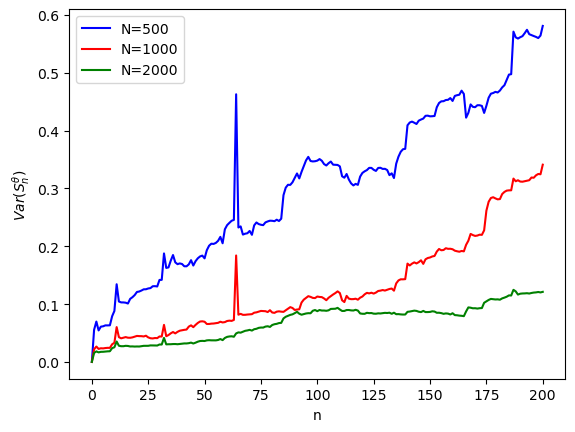

In [508]:
plt.plot(timesteps,np.var(S_500,axis=0),color="blue",label="N=500")
plt.plot(timesteps,np.var(S_1000,axis=0),color="red",label="N=1000")
plt.plot(timesteps,np.var(S_2000,axis=0),color="green",label="N=2000")
plt.xlabel("n")
plt.ylabel(r"$Var(S_n^{\theta})$")
plt.legend()

#### Old redundant code I used to check algorithm works as intended

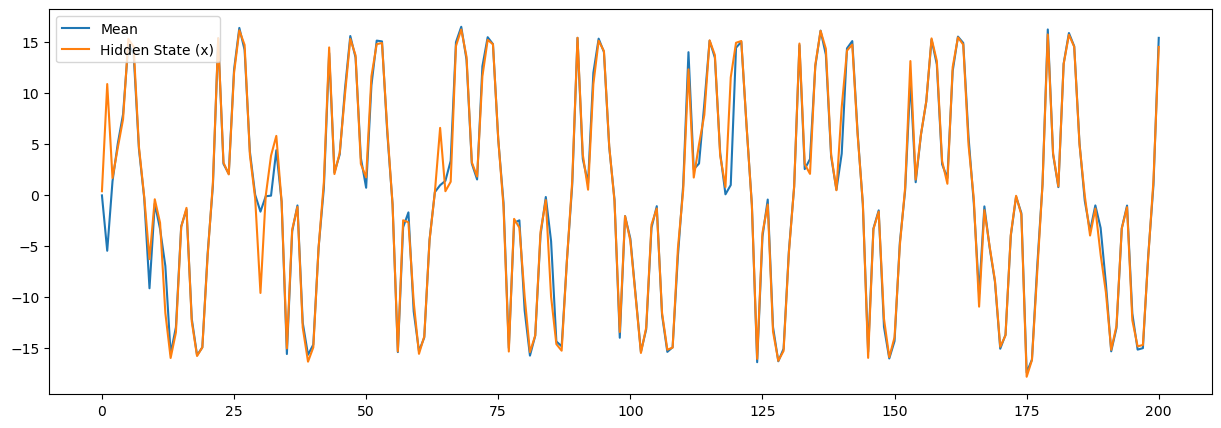

In [20]:
plt.figure(figsize=(15,5))
plt.plot(timesteps,np.sum(samples*weights,axis=0),label="Mean")
plt.plot(timesteps,hidden_state,label="Hidden State (x)")
plt.legend()

Functions for two smoothing methods are written below, but prefer FFBSa because it directly addresses path degeneracy issue, whereas the lineages are still the same using FFBSm. Also, it is slightly simpler because all the particles are equally weighted afterwards.

In [ ]:
def FFBSm(y,N):

    # Get length of observations
    T = len(y)

    # Run SIR forwards once
    X, samples, weights = SIR(y,N)

    # Recursively compute conditional weights backwards
    conditional_weights = np.zeros((N,T))
    conditional_weights[:,T] = weights[:,T]

    for k in range(1,T):
        # Get true index so that n goes T-1, T-2, ..., 0
        n = T-k
        
        weighted_transition = np.log(weights[:,n+1]) + log_f(X[:,n+1],X[:,n],n+1)
        denominator = np.sum(np.exp(weighted_transition),axis=0)

        numerator = np.exp(np.log(conditional_weights[:,n+1]) + log_f(X[:,n+1],X[:,n],n+1),axis=0)

        conditional_weights[:,n] = weights[:,n]*np.sum(numerator/denominator,axis=0)

    return samples, conditional_weights

In [47]:
def FFBSa(y,N,n_paths):

    # Get length of observations
    T = len(y)

    # Run SIR forwards once
    X, samples, weights = SIR(y,N)

    new_samples = np.zeros((n_paths,T))

    # Sample starting particles from final distribution with replacement
    rng1 = np.random.default_rng(i)
    indices = stats.randint.rvs(0,N,size=n_paths,random_state=rng1)
    new_samples[:,T-1] = samples[indices,T-1]

    # Recursively sample particles at each timestep to generate n_paths new lineages
    for j in range(2,T+1):
        n = T-j

        # Calculate probabilities using sample from next time step
        log_p = np.log(weights[:,n]) + log_f(new_samples[:,n+1],samples[:,n],n+1)
        max_val = np.max(log_p)
        p = np.exp(log_p-max_val)/np.sum(np.exp(log_p-max_val))

        # Sample a new ancestor from probabilities and add it to new samples
        rng2 = np.random.default_rng(j)
        ancestor_indices = stats.multinomial.rvs(n_paths,p,random_state=rng2)
        new_samples[:,n] = samples[ancestor_indices,n]

    return new_samples

In [48]:
new_samples = FFBSa(y,N=500,n_paths=500)

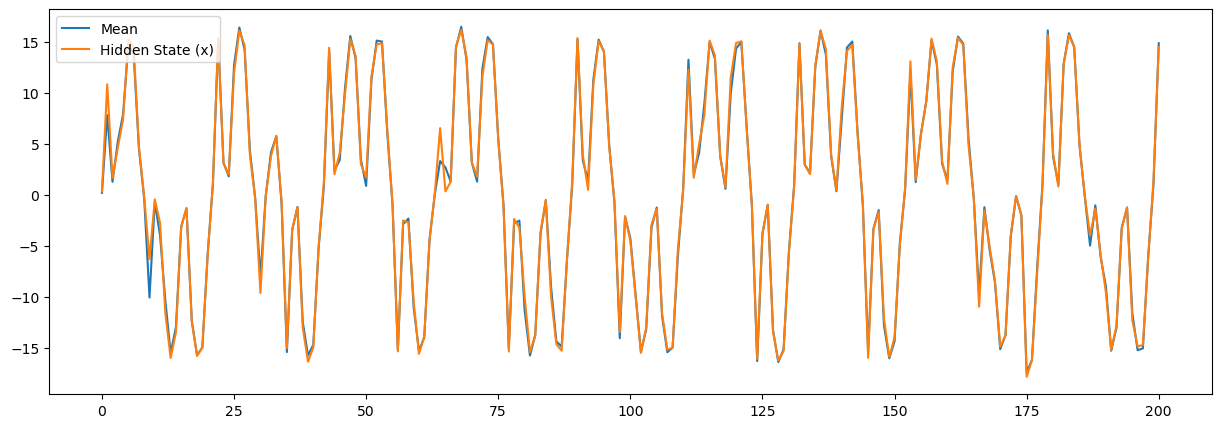

In [49]:
plt.figure(figsize=(15,5))
plt.plot(timesteps,np.mean(new_samples,axis=0),label="Mean")
plt.plot(timesteps,hidden_state,label="Hidden State (x)")
plt.legend()